# Plotting Notebook (auto from artifacts)

This notebook loads the **latest** run exported by your analysis notebook and produces figures.
It is **name-agnostic**: it uses the `meta` attached to the artifacts (when available) to
find all summary tables and the "everything" table. It falls back to simple heuristics if
those keys are missing.


## Workflow

1. In the analysis notebook, run the export cell (right before any plotting) to write Parquet tables
   and a `meta.json` into a timestamped folder under `artifacts/`.
2. Open this notebook and run the cells top-to-bottom to generate figures from the latest run.
3. Figures are saved under `plots/<run_id>/` so every run remains reproducible.


In [1]:
# Load artifacts and resolve summary + everything tables
import os
import pandas as pd
from artifacts_io import load_artifacts
import seaborn as sns

tables, meta, run_dir = load_artifacts(out_dir="artifacts")
run_id = os.path.basename(run_dir)
print("Loaded run:", run_dir)
print("Meta:", meta)

# Resolve keys from meta if present; otherwise infer
summary_keys = meta.get("summary_keys", [])
everything_key = meta.get("everything_key")

if not summary_keys:
    # Heuristic: names containing common summary tokens
    name_hits = ("summary", "sum_", "_sum", "agg", "group", "pivot", "tbl", "by_", "_by")
    summary_keys = [k for k in tables if any(tok in k.lower() for tok in name_hits)]

if everything_key is None:
    # Largest table by rows as the 'everything' table
    everything_key = max(tables, key=lambda k: tables[k].shape[0])

print("\nResolved table keys:")
print("  summary_keys :", summary_keys if summary_keys else "(none)")
print("  everything_key:", everything_key)

# Preview heads
for k in tables:
    print(f"\nTable: {k}  shape={tables[k].shape}")
    display(tables[k].head(5))


Loaded run: artifacts\run_20250829_115143
Meta: {'created': '2025-08-29 11:51:43', 'n_tables': 5, 'notes': 'Summaries + full analysis table exported for plotting/other notebooks', 'source_notebook': 'working_datacrunch.ipynb', 'summary_keys': ['df_summary', 'summary_by_type', 'summary_by_year', 'summary_by_decade'], 'everything_key': 'df'}

Resolved table keys:
  summary_keys : ['df_summary', 'summary_by_type', 'summary_by_year', 'summary_by_decade']
  everything_key: df

Table: df  shape=(107314, 27)


,id,page_number,inferred_latitude,inferred_longitude,actual_latitude,actual_longitude,location,townships_ranges_sections,watersource_name,actual_county,...,latitude,longitude,water_type_clean,water_type_review,year_start,year_end,years_list,date_parse_status,date_parse_notes,needs_date_review
0,70038399,445,,,39.13472,-120.94833,"NEASE sec.22, T.15 N., R.9 E.","['T.15 N., R.9 E., SEC. 22']",Rollins Reservoir,Placer County,...,39.134720,-120.948330,Reservoir,None,1964,1966,"[1964, 1966]",EXACT_RANGE,None,False
1,553,177,,,35.933333,-118.483333,"NE sec. 14 T. 23 S., R. 32 E., 3 miles upstrea...","['T. 23 S., R. 32 E., NE sec. 14']",Kern River near Kernville,Tehama County,...,35.933333,-118.483333,Stream discharge,None,1912,1942,"[1912, 1942]",EXACT_RANGE,None,False
2,455,159,,,,,"Near La Grange, California",['3S 14E NE 1/4 sec. 3'],TUOLUMNE RIVER ABOVE LA GRANGE DAM,Tuolumne County,...,NaN,NaN,Stream discharge,None,1929,1930,"[1929, 1930]",EXACT_RANGE,None,False
3,251,43,,,32.81666667,-114.5,"Near Yuma, Arizona","['T. 15 S., R. 23 E.', 'SE1 sec. 10, T. 16 S.,...",Yuma Main Canal,Imperial County,...,32.816667,-114.500000,Stream discharge,None,1910,1938,"[1910, 1938]",EXACT_RANGE,None,False
4,2850,45,38.5,-122.0,,,Coyote Valley,,Putah Creek,,...,38.500000,-122.000000,Stream discharge,None,<NA>,<NA>,None,UNPARSED,None,True



Table: df_summary  shape=(106220, 28)


,id,page_number,inferred_latitude,inferred_longitude,actual_latitude,actual_longitude,location,townships_ranges_sections,watersource_name,actual_county,...,longitude,water_type_clean,water_type_review,year_start,year_end,years_list,date_parse_status,date_parse_notes,needs_date_review,decade
0,70038399,445,,,39.13472,-120.94833,"NEASE sec.22, T.15 N., R.9 E.","['T.15 N., R.9 E., SEC. 22']",Rollins Reservoir,Placer County,...,-120.948330,Reservoir,None,1964,1966,"[1964, 1966]",EXACT_RANGE,None,False,1960
1,553,177,,,35.933333,-118.483333,"NE sec. 14 T. 23 S., R. 32 E., 3 miles upstrea...","['T. 23 S., R. 32 E., NE sec. 14']",Kern River near Kernville,Tehama County,...,-118.483333,Stream discharge,None,1912,1942,"[1912, 1942]",EXACT_RANGE,None,False,1910
2,455,159,,,,,"Near La Grange, California",['3S 14E NE 1/4 sec. 3'],TUOLUMNE RIVER ABOVE LA GRANGE DAM,Tuolumne County,...,NaN,Stream discharge,None,1929,1930,"[1929, 1930]",EXACT_RANGE,None,False,1920
3,251,43,,,32.81666667,-114.5,"Near Yuma, Arizona","['T. 15 S., R. 23 E.', 'SE1 sec. 10, T. 16 S.,...",Yuma Main Canal,Imperial County,...,-114.500000,Stream discharge,None,1910,1938,"[1910, 1938]",EXACT_RANGE,None,False,1910
4,2850,45,38.5,-122.0,,,Coyote Valley,,Putah Creek,,...,-122.000000,Stream discharge,None,<NA>,<NA>,None,UNPARSED,None,True,<NA>



Table: summary_by_decade  shape=(106, 5)


,water_type_clean,decade,n_rows,n_pages,n_docs
0,Groundwater,1850,1,1,1
1,Groundwater,1860,10,8,6
2,Groundwater,1870,91,78,11
3,Groundwater,1880,263,141,17
4,Groundwater,1890,427,142,19



Table: summary_by_type  shape=(9, 4)


,water_type_clean,n_rows,n_pages,n_docs
0,Groundwater,18961,5162,374
1,Irrigation,2317,1372,245
2,Not water related,741,360,188
3,Other,9,5,2
4,Precipitation,906,358,149



Table: summary_by_year  shape=(750, 5)


,water_type_clean,year_start,n_rows,n_pages,n_docs
0,Groundwater,1856,1,1,1
1,Groundwater,1860,1,1,1
2,Groundwater,1863,1,1,1
3,Groundwater,1865,2,2,2
4,Groundwater,1866,1,1,1


## Prep for mapping

In [2]:
# ==== Build combined coordinates from df_summary (actual > inferred) ====
import re
import numpy as np
import pandas as pd

# 0) Select the df_summary table from artifacts
if "tables" not in globals():
    raise RuntimeError("Run the artifacts loading cell first.")

if "df_summary" in tables:
    df_summary = tables["df_summary"].copy()
else:
    # case-insensitive match if key differs in case
    match_keys = [k for k in tables if k.lower() == "df_summary"]
    if not match_keys:
        raise KeyError("I can't find a table named 'df_summary' in artifacts.")
    df_summary = tables[match_keys[0]].copy()

print("df_summary shape:", df_summary.shape)

# ---------- Optional: set explicit column names here if you already know them ----------
# If you know the exact names, set them (strings) and this will override auto-detection below.
EXPLICIT_LAT_ACTUAL = None   # e.g., "Latitude_actual"
EXPLICIT_LAT_INFER  = None   # e.g., "Latitude_inferred"
EXPLICIT_LON_ACTUAL = None   # e.g., "Longitude_actual"
EXPLICIT_LON_INFER  = None   # e.g., "Longitude_inferred"
# -----------------------------------------------------------------------

def _coerce_num(s):
    return pd.to_numeric(s, errors="coerce")

def _first_nonnull(series_list, index):
    if not series_list:
        return pd.Series(index=index, dtype="float64")
    stacked = pd.concat([_coerce_num(s) for s in series_list], axis=1)
    return stacked.bfill(axis=1).iloc[:, 0]

def _find_cols(df, lat_or_lon, which):
    """
    lat_or_lon: 'lat' or 'lon'
    which: 'actual' or 'inferred'
    """
    pat_lat = r'(?:\blat\b|latitude)'
    pat_lon = r'(?:\blon\b|\blong\b|longitude)'
    pat_kind = r'actual' if which == "actual" else r'infer|inferred|estimat|approx'
    cols = []
    for c in df.columns:
        cl = c.lower()
        if (re.search(pat_lat, cl) if lat_or_lon=='lat' else re.search(pat_lon, cl)) and re.search(pat_kind, cl):
            cols.append(c)
    return cols

def _fallback_cols(df, lat_or_lon):
    pat = r'(?:\blat\b|latitude)' if lat_or_lon=='lat' else r'(?:\blon\b|\blong\b|longitude)'
    return [c for c in df.columns if re.search(pat, c.lower())]

# 1) Gather candidate columns (prefer explicit names if provided)
lat_actual_cols = [EXPLICIT_LAT_ACTUAL] if (EXPLICIT_LAT_ACTUAL and EXPLICIT_LAT_ACTUAL in df_summary.columns) else _find_cols(df_summary, 'lat','actual')
lat_infer_cols  = [EXPLICIT_LAT_INFER]  if (EXPLICIT_LAT_INFER  and EXPLICIT_LAT_INFER  in df_summary.columns) else _find_cols(df_summary, 'lat','inferred')
lon_actual_cols = [EXPLICIT_LON_ACTUAL] if (EXPLICIT_LON_ACTUAL and EXPLICIT_LON_ACTUAL in df_summary.columns) else _find_cols(df_summary, 'lon','actual')
lon_infer_cols  = [EXPLICIT_LON_INFER]  if (EXPLICIT_LON_INFER  and EXPLICIT_LON_INFER  in df_summary.columns) else _find_cols(df_summary, 'lon','inferred')

# Fallbacks if column names don’t contain 'actual'/'inferred'
if not (lat_actual_cols or lat_infer_cols):
    lat_infer_cols = _fallback_cols(df_summary, 'lat')
if not (lon_actual_cols or lon_infer_cols):
    lon_infer_cols = _fallback_cols(df_summary, 'lon')

lat_names_order = lat_actual_cols + lat_infer_cols
lon_names_order = lon_actual_cols + lon_infer_cols

lat_sources = [df_summary[c] for c in lat_names_order if c in df_summary.columns]
lon_sources = [df_summary[c] for c in lon_names_order if c in df_summary.columns]

if not lat_sources or not lon_sources:
    raise ValueError("Couldn’t find latitude/longitude columns. If you know them, set the EXPLICIT_* names above.")

# 2) Build combined columns (actual → inferred)
df_summary["lat_combined"] = _first_nonnull(lat_sources, df_summary.index)
df_summary["lon_combined"] = _first_nonnull(lon_sources, df_summary.index)

# 3) Normalize longitudes and fix obvious lat/lon swaps
def _normalize_lon(x):
    # bring into [-180, 180]
    return ((x + 180) % 360) - 180

if (df_summary["lon_combined"] > 180).mean() > 0.2:
    df_summary["lon_combined"] = _normalize_lon(df_summary["lon_combined"])

swap_mask = (~df_summary["lat_combined"].between(-90, 90)) & (df_summary["lon_combined"].between(-90, 90))
if swap_mask.any():
    df_summary.loc[swap_mask, ["lat_combined","lon_combined"]] = (
        df_summary.loc[swap_mask, ["lon_combined","lat_combined"]].to_numpy()
    )

# 4) Record which source column was used (NaN-safe)
def _first_used_name(series_list, names):
    out = np.full(len(df_summary), np.nan, dtype=object)
    for s, n in zip(series_list, names):
        take = pd.isna(out) & ~_coerce_num(s).isna()
        out[take.values] = n
    return pd.Series(out, index=df_summary.index)

df_summary["lat_source_col"] = _first_used_name([df_summary[c] for c in lat_names_order], lat_names_order) if lat_names_order else np.nan
df_summary["lon_source_col"] = _first_used_name([df_summary[c] for c in lon_names_order], lon_names_order) if lon_names_order else np.nan

def _safe_tag(val):
    if not isinstance(val, str):
        return "unspecified"
    v = val.lower()
    if "actual" in v:
        return "actual"
    if "infer" in v or "estimat" in v or "approx" in v:
        return "inferred"
    return "unspecified"

df_summary["coord_source"] = [
    _safe_tag(la) if _safe_tag(la) == _safe_tag(lo) else f"{_safe_tag(la)}/{_safe_tag(lo)}"
    for la, lo in zip(df_summary["lat_source_col"], df_summary["lon_source_col"])
]

# 5) Drop invalid coordinates
valid = df_summary["lat_combined"].between(-90, 90) & df_summary["lon_combined"].between(-180, 180)
dropped = (~valid).sum()
df_summary = df_summary.loc[valid].copy()

print(f"Combined coordinates built. Dropped {dropped} rows with invalid/missing coords.")
print("coord_source breakdown:")
print(df_summary["coord_source"].value_counts(dropna=False))
print("Preview:")
display(df_summary[[
    *(lat_names_order[:1] or []), *(lon_names_order[:1] or []),
    "lat_combined","lon_combined","coord_source"
]].head(10))



df_summary shape: (106220, 28)
Combined coordinates built. Dropped 7511 rows with invalid/missing coords.
coord_source breakdown:
coord_source
actual             57315
inferred           41383
actual/inferred        8
inferred/actual        3
Name: count, dtype: int64
Preview:


,actual_latitude,actual_longitude,lat_combined,lon_combined,coord_source
0,39.13472,-120.94833,39.134720,-120.948330,actual
1,35.933333,-118.483333,35.933333,-118.483333,actual
3,32.81666667,-114.5,32.816667,-114.500000,actual
4,,,38.500000,-122.000000,inferred
5,,,38.500000,-122.000000,inferred
6,,,38.500000,-122.000000,inferred
7,,,38.500000,-122.000000,inferred
8,,,38.696900,-121.767200,inferred
9,36.216111,-118.871667,36.216111,-118.871667,actual
10,,,35.333300,-118.516700,inferred


## Filter out "Not water related" and "other" 

In [3]:
# Add this filtering code RIGHT AFTER the coordinate preparation step
# (after the line: print(f"Combined coordinates built. Dropped {dropped} rows with invalid/missing coords."))

print(f"\n=== WATER TYPE FILTERING ===")

# Check current water_type_clean distribution
if 'water_type_clean' in df_summary.columns:
    print("Current water_type_clean distribution:")
    water_counts = df_summary['water_type_clean'].value_counts(dropna=False)
    print(water_counts)
    
    # Filter out unwanted categories
    exclude_categories = ['Not water related', 'Other']  # Note: using the clean display names
    
    # Create mask to keep only water-related categories
    water_mask = ~df_summary['water_type_clean'].isin(exclude_categories)
    
    # Apply filter
    df_summary_before = len(df_summary)
    df_summary = df_summary[water_mask].copy()
    df_summary_after = len(df_summary)
    
    excluded_count = df_summary_before - df_summary_after
    
    print(f"\nFiltering results:")
    print(f"  - Before filtering: {df_summary_before:,} rows")
    print(f"  - After filtering: {df_summary_after:,} rows") 
    print(f"  - Excluded: {excluded_count:,} rows ({excluded_count/df_summary_before*100:.1f}%)")
    
    # Show remaining categories
    print(f"\nRemaining water categories:")
    remaining_counts = df_summary['water_type_clean'].value_counts(dropna=False)
    print(remaining_counts)
    
else:
    print("WARNING: 'water_type_clean' column not found in df_summary!")
    print("Available columns:", list(df_summary.columns))

print("="*50)


=== WATER TYPE FILTERING ===
Current water_type_clean distribution:
water_type_clean
Stream discharge     72639
Groundwater          16216
Reservoir             4245
Irrigation            2109
Springs               1891
Precipitation          861
Not water related      502
Water quality          239
Other                    7
Name: count, dtype: int64

Filtering results:
  - Before filtering: 98,709 rows
  - After filtering: 98,200 rows
  - Excluded: 509 rows (0.5%)

Remaining water categories:
water_type_clean
Stream discharge    72639
Groundwater         16216
Reservoir            4245
Irrigation           2109
Springs              1891
Precipitation         861
Water quality         239
Name: count, dtype: int64


## Plotting maps 

Using full USA bounds: (-130.0, 20.0, -60.0, 52.0)


C:\Users\aeliz\AppData\Local\Temp\ipykernel_31752\2128646360.py:43: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  usa_boundary = states.unary_union


Loaded custom states shapefile: data/usa_shapefile/CUSA_States.shp
Clipped 98200 points to 96499 points within USA boundary

=== DECADE INFORMATION FOR ORIGINAL DATA (DF_SUMMARY) ===
Decade range: 1810 - 1980
Unique decades: [np.int64(1810), np.int64(1820), np.int64(1830), np.int64(1840), np.int64(1850), np.int64(1860), np.int64(1870), np.int64(1880), np.int64(1890), np.int64(1900), np.int64(1910), np.int64(1920), np.int64(1930), np.int64(1940), np.int64(1950), np.int64(1960), np.int64(1970), np.int64(1980)]
Number of records per decade:
  1810: 1 records
  1820: 1 records
  1830: 2 records
  1840: 19 records
  1850: 22 records
  1860: 283 records
  1870: 369 records
  1880: 573 records
  1890: 1801 records
  1900: 6785 records
  1910: 10589 records
  1920: 9043 records
  1930: 6622 records
  1940: 7650 records
  1950: 9888 records
  1960: 18716 records
  1970: 12088 records
  1980: 4 records
Total records with decade info: 84456

=== DECADE INFORMATION FOR USA CLIPPED DATA (GDF_USA) =

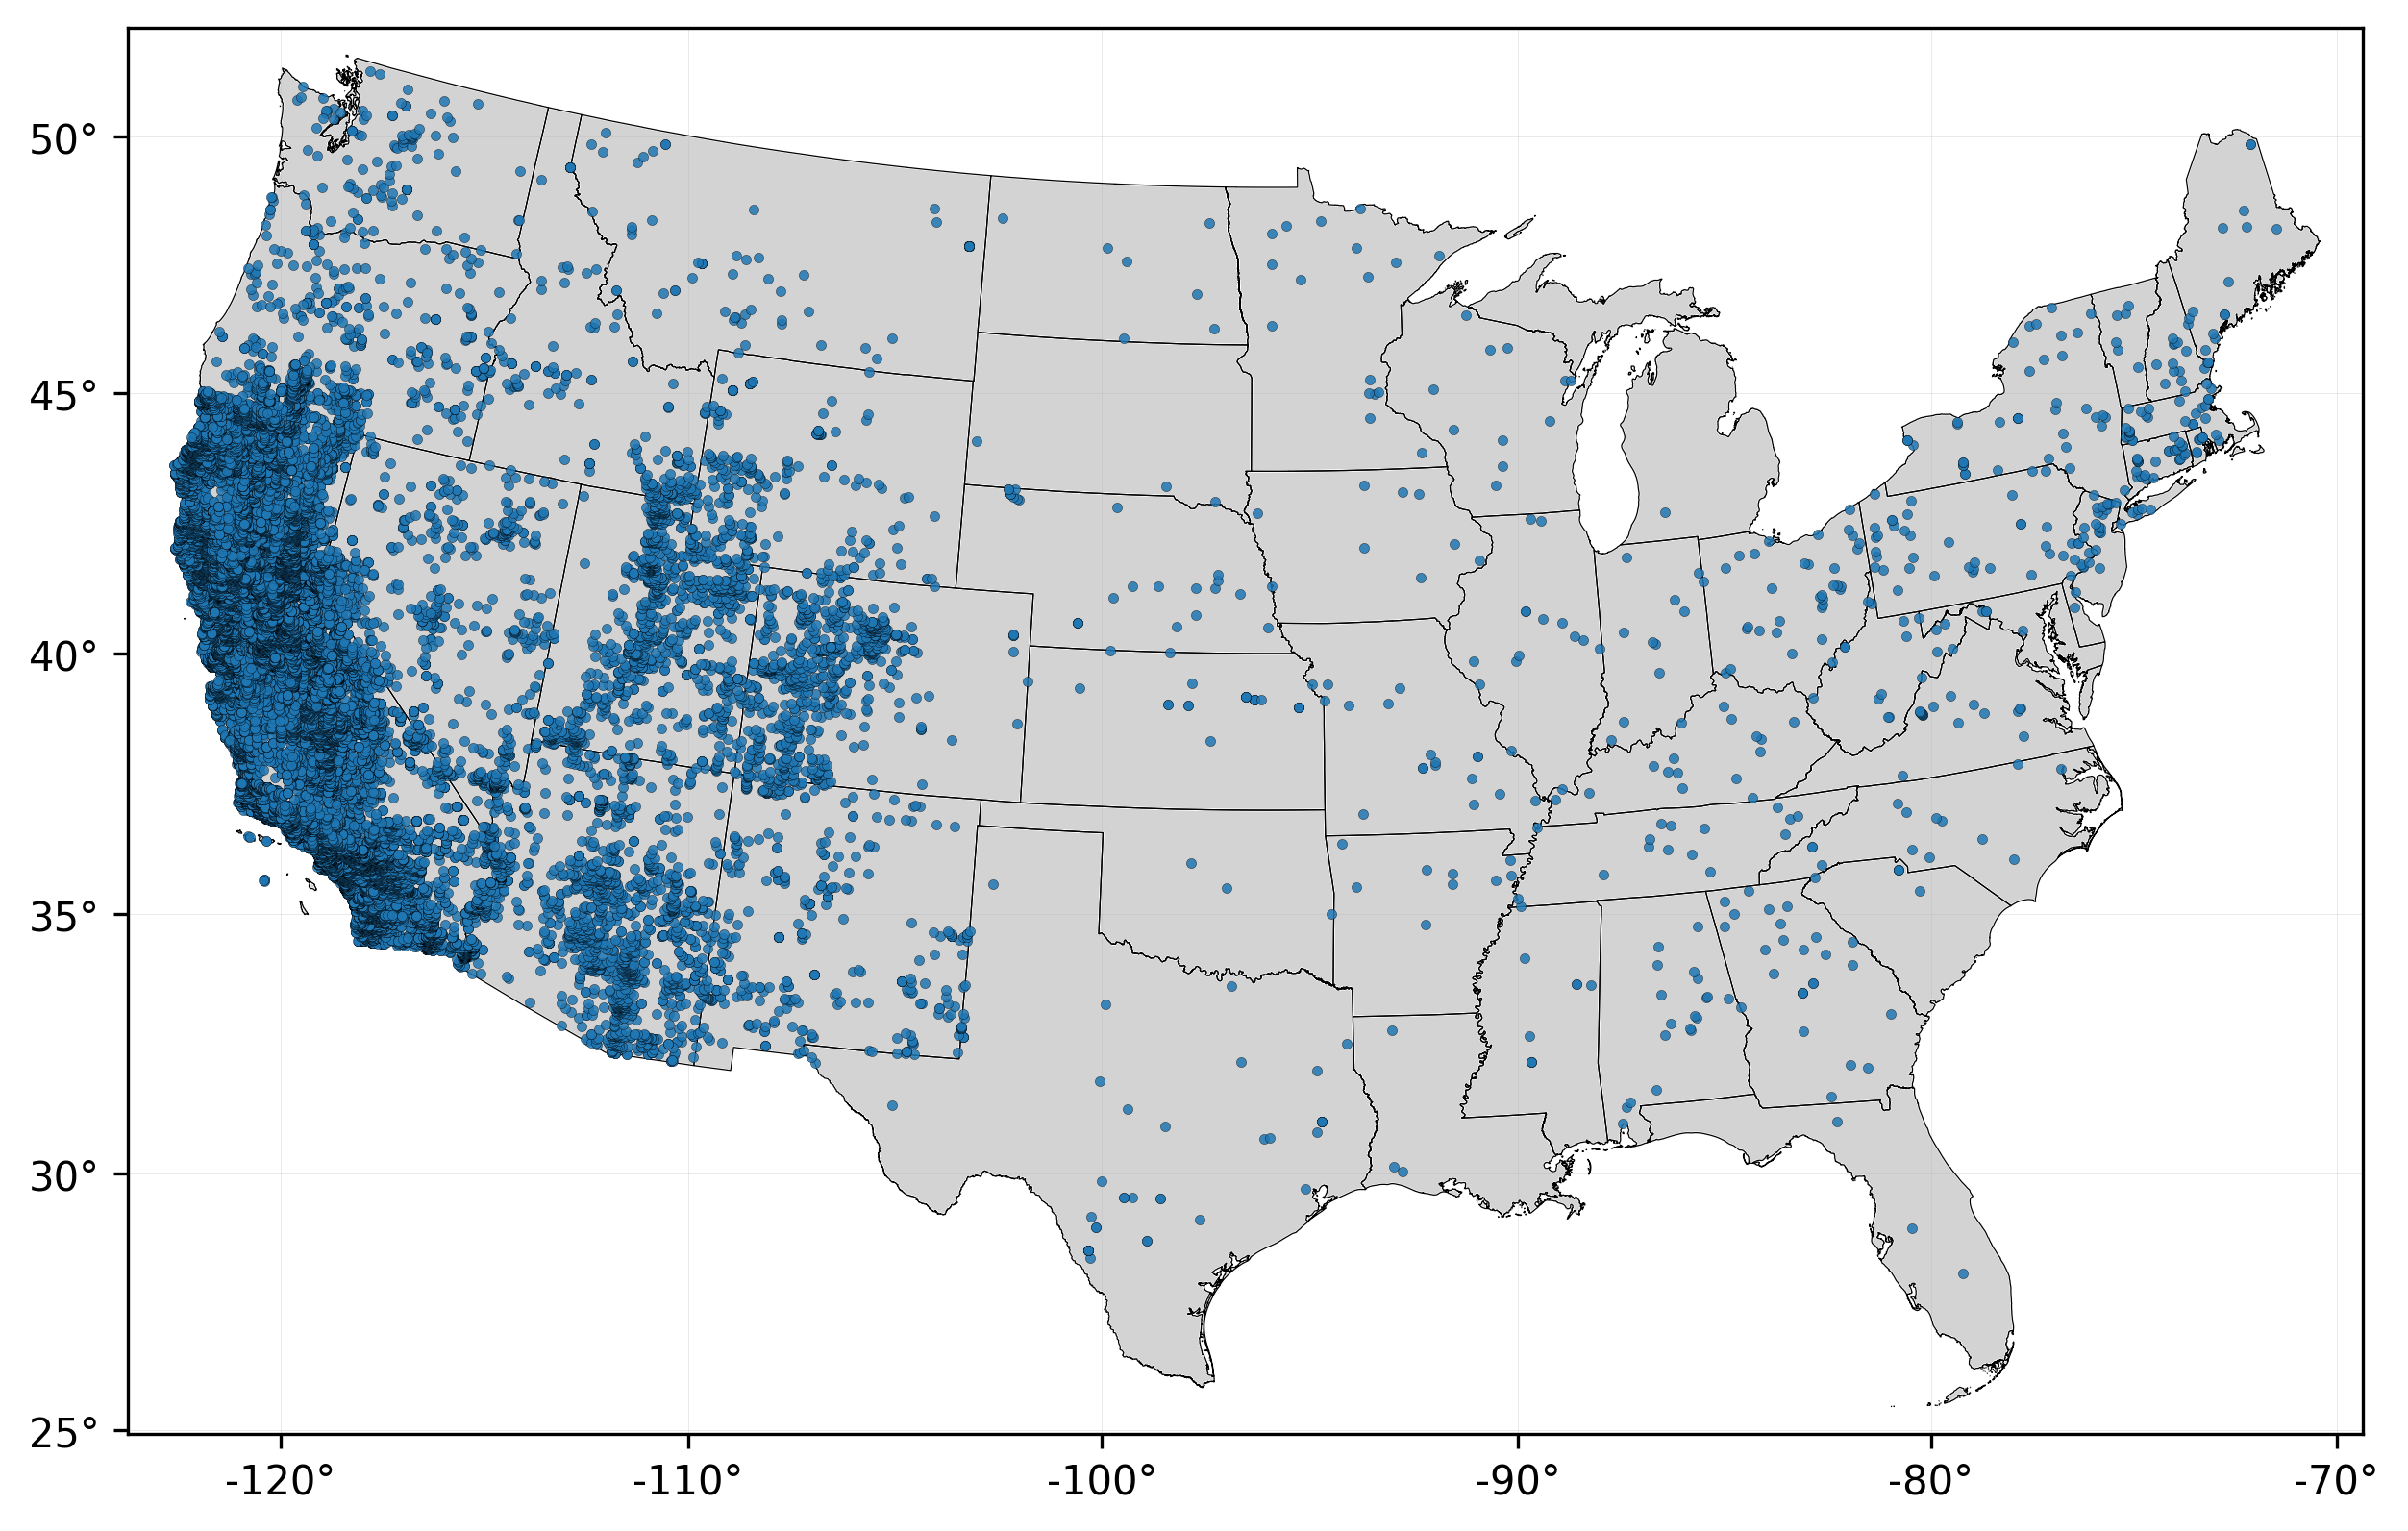

Saved: plots\run_20250829_115143\all_sites_us_static_ACTUAL_vs_INFERRED.png


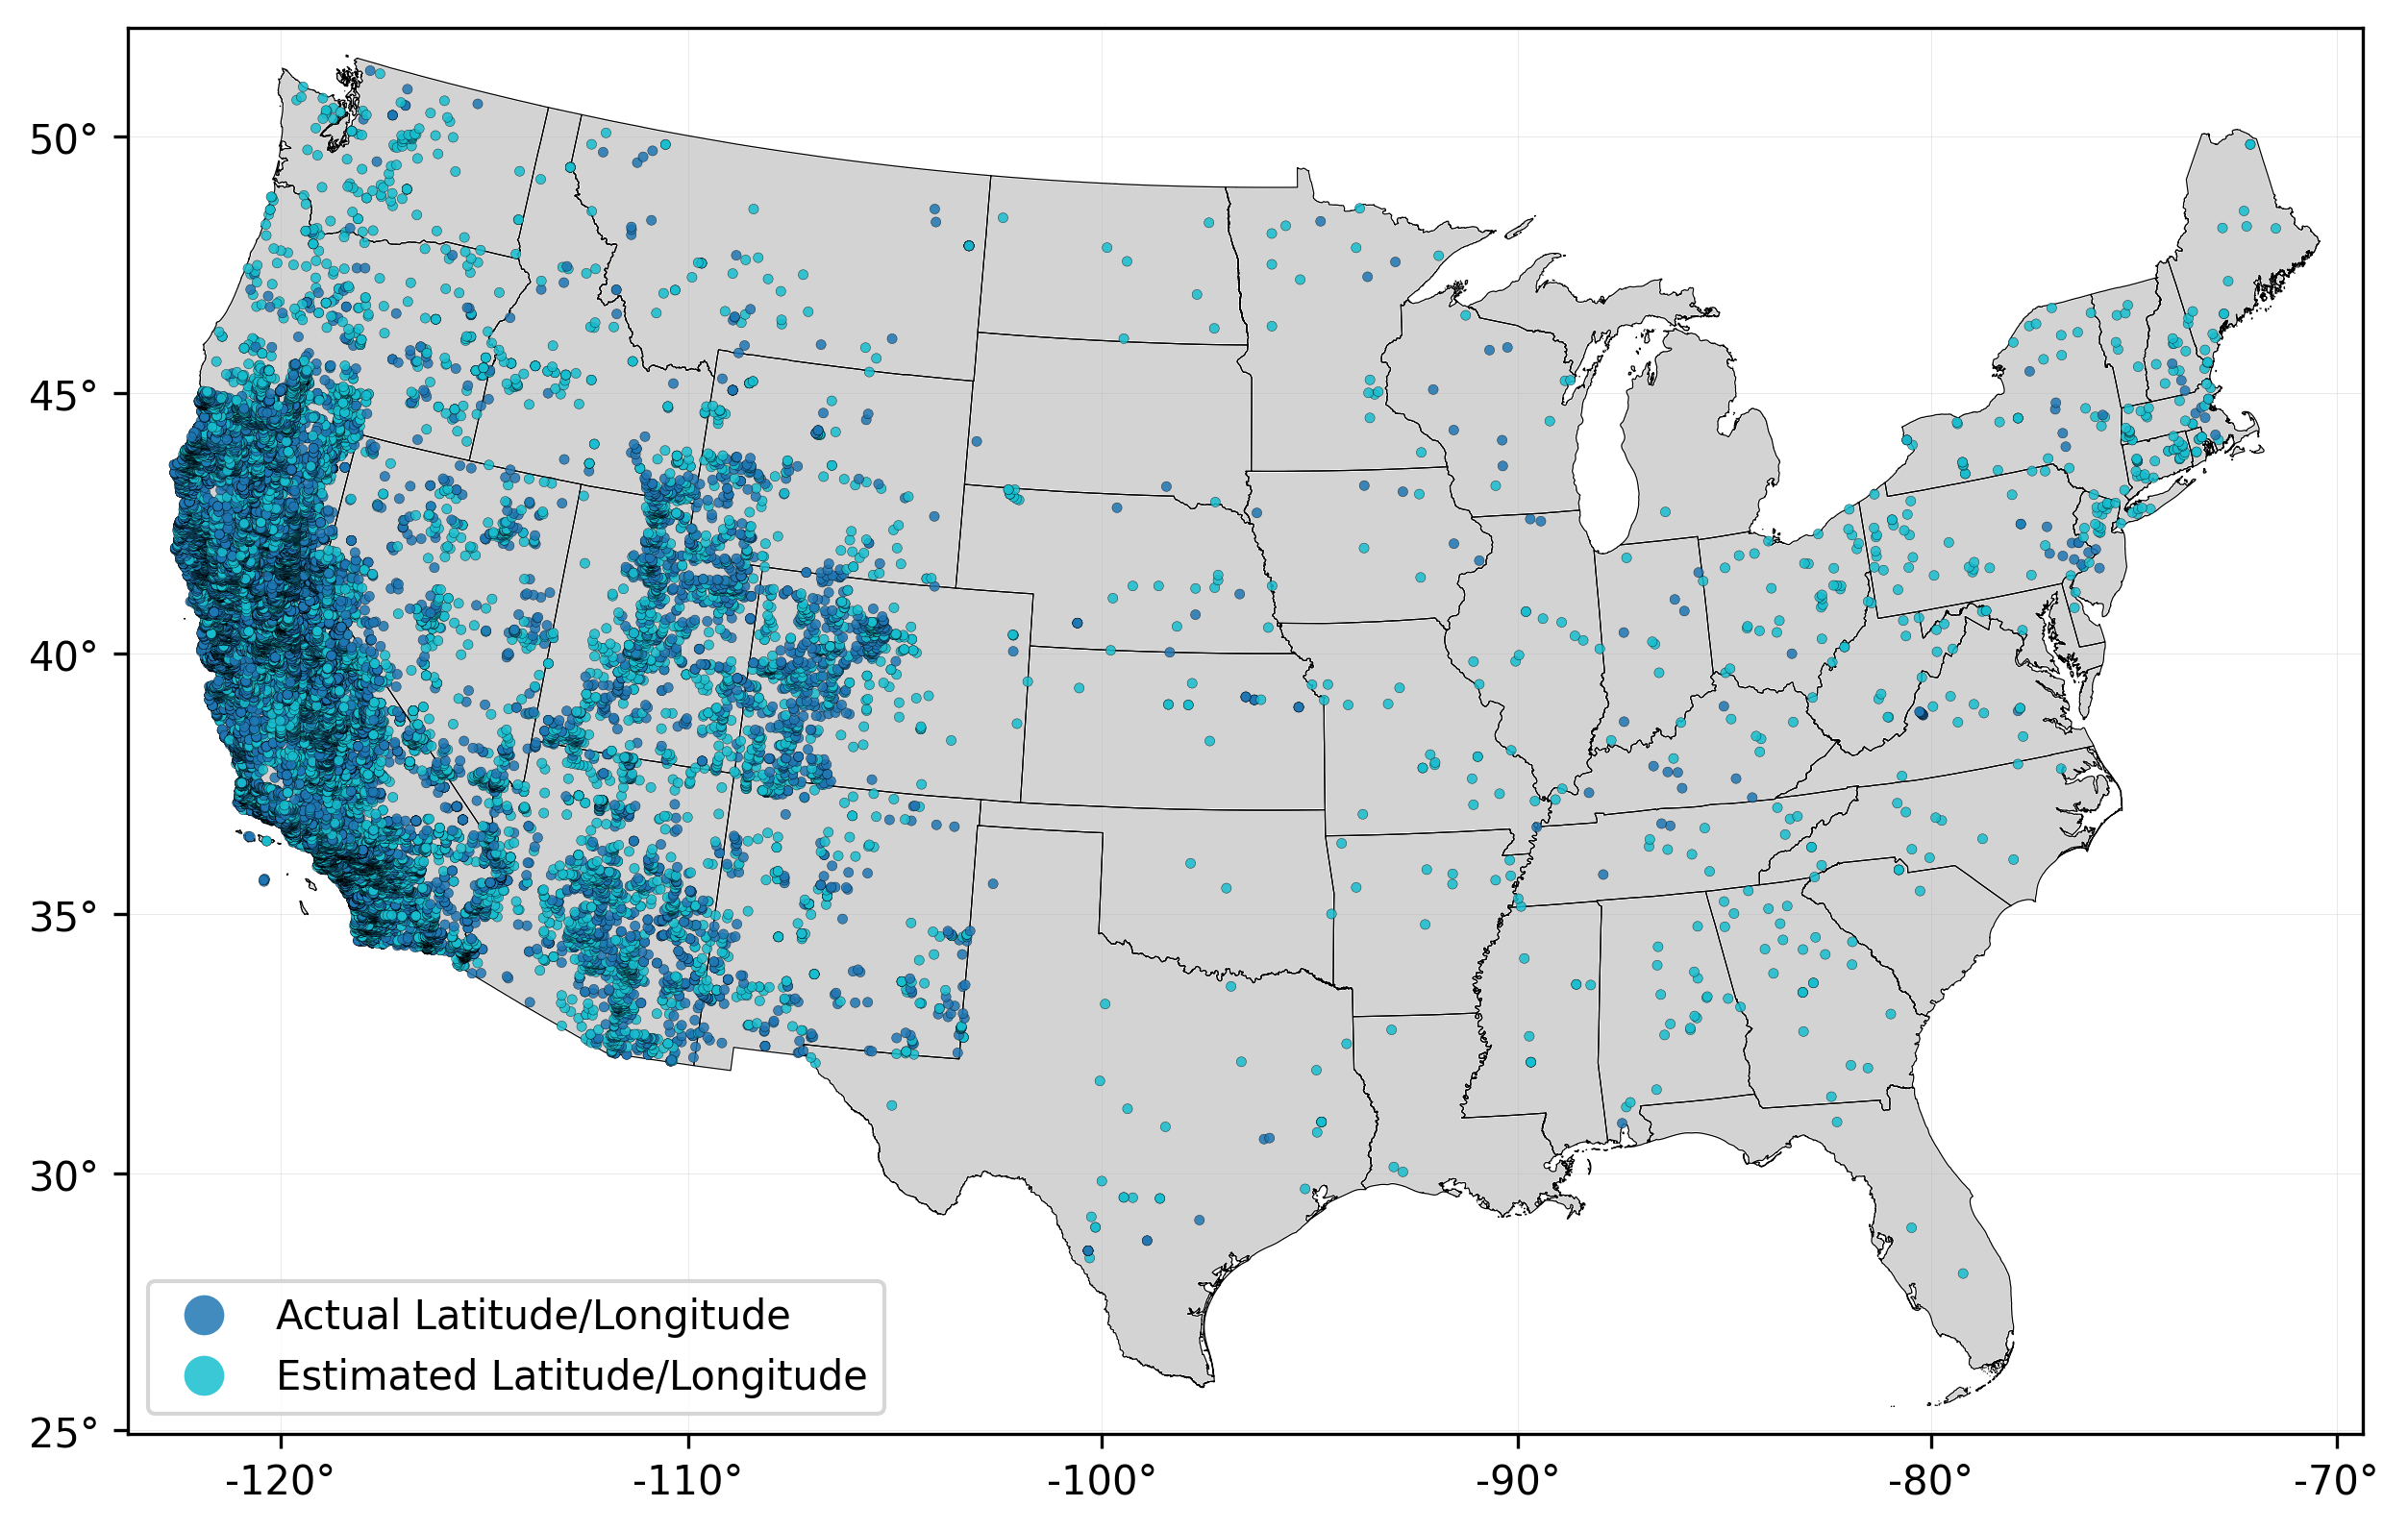

In [5]:
# ==== Static maps with custom state outlines shapefile ====
import os
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

# deps - geodatasets no longer required since we're using custom shapefile
try:
    import geodatasets
except Exception as e:
    print("Note: geodatasets not available, but not needed since using custom shapefile")

# Path to your custom USA states shapefile
CUSTOM_STATES_PATH = "data/usa_shapefile/CUSA_States.shp"

# Projection options (uncomment the one you prefer):
# PROJ_CRS = "EPSG:5070"    # Albers Equal Area Conic (CONUS) - RECOMMENDED
# PROJ_CRS = "EPSG:2163"    # US National Atlas Equal Area
# PROJ_CRS = "EPSG:3857"    # Web Mercator (familiar but distorted)
PROJ_CRS = "EPSG:5070"      # Default: Albers Equal Area

def calculate_bounds(gdf, target_crs=PROJ_CRS):
    """Calculate bounds to show the entire USA"""
    # Use full CONUS bounds instead of data-driven bounds to ensure entire USA is visible
    # Extended bounds to ensure no state is cut off
    full_usa_bounds = (-130.0, 20.0, -60.0, 52.0)  # Extended beyond CONUS to include all states
    
    print(f"Using full USA bounds: {full_usa_bounds}")
    return full_usa_bounds

def load_context_layers(bounds, target_crs=PROJ_CRS):
    """Load USA states shapefile for boundaries and clipping"""
    # Custom states shapefile (serves as both boundaries and USA boundary for clipping)
    states_region = None
    usa_boundary = None
    if os.path.exists(CUSTOM_STATES_PATH):
        try:
            states = gpd.read_file(CUSTOM_STATES_PATH).to_crs(target_crs)
            # Don't clip states - we want to see all of them
            states_region = states
            
            # Create USA boundary for clipping points
            usa_boundary = states.unary_union
            print(f"Loaded custom states shapefile: {CUSTOM_STATES_PATH}")
        except Exception as e:
            print(f"Warning: Could not load custom shapefile: {e}")
            states_region = None
    else:
        print(f"Warning: Custom shapefile not found at {CUSTOM_STATES_PATH}")
    
    return states_region, usa_boundary

def clip_points_to_usa(gdf, usa_boundary, target_crs=PROJ_CRS):
    """Clip points to USA boundary"""
    if usa_boundary is None:
        print("Warning: No USA boundary available for clipping")
        return gdf
    
    # Convert to target projection for clipping
    gdf_proj = gdf.to_crs(target_crs)
    
    # Clip points to USA boundary
    gdf_clipped = gpd.clip(gdf_proj, usa_boundary)
    
    print(f"Clipped {len(gdf)} points to {len(gdf_clipped)} points within USA boundary")
    return gdf_clipped

def plot_base_layers(ax, states_region, usa_boundary=None):
    """Plot state boundary layers only"""
    # Set white background
    ax.set_facecolor('white')
    
    # Fill states with light gray, then add boundaries
    if states_region is not None and not states_region.empty:
        # Fill states with light gray background
        states_region.plot(ax=ax, color="lightgray", edgecolor="none", zorder=0)
        
        try:
            # Double-line effect for state boundaries
            states_region.boundary.plot(ax=ax, color="white", linewidth=0.6, zorder=1)
            states_region.boundary.plot(ax=ax, color="black", linewidth=0.3, zorder=2)
        except AttributeError:
            # Fallback if boundary method doesn't work
            states_region.plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.4, zorder=2)

def create_map(gdf, bounds, states_region, title, filename, color_column=None, color="C0", outdir="plots", target_crs=PROJ_CRS, usa_boundary=None):
    """Create a standardized map with given parameters"""
    # For lat/lon display, work with WGS84 bounds regardless of plotting projection
    xmin_wgs84, ymin_wgs84, xmax_wgs84, ymax_wgs84 = bounds
    
    # Calculate projected bounds with padding for plotting
    proj_bounds = gdf.total_bounds
    
    fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
    fig.patch.set_facecolor('white')  # Set figure background to white
    
    # Plot base layers
    plot_base_layers(ax, states_region, usa_boundary)
    
    # Plot points with custom legend labels
    if color_column:
        # Create a copy with renamed categories for legend
        gdf_plot = gdf.copy()
        legend_mapping = {
            'actual': 'Actual Latitude/Longitude',
            'inferred': 'Estimated Latitude/Longitude'
        }
        gdf_plot[color_column] = gdf_plot[color_column].map(legend_mapping).fillna(gdf_plot[color_column])
        
        gdf_plot.plot(
            ax=ax,
            column=color_column,
            categorical=True,
            legend=True,
            markersize=6,
            alpha=0.85,
            edgecolor="k",
            linewidth=0.1,
            zorder=3,
        )
    else:
        gdf.plot(
            ax=ax,
            color=color,
            markersize=6,
            alpha=0.85,
            edgecolor="k",
            linewidth=0.1,
            zorder=3,
        )
    
    # Set map extent to ensure full USA coverage
    if target_crs != "EPSG:4326":
        # For projected coordinates, calculate the full extent from the states
        if states_region is not None and not states_region.empty:
            full_bounds = states_region.total_bounds
            # Add small padding
            pad_x = (full_bounds[2] - full_bounds[0]) * 0.02
            pad_y = (full_bounds[3] - full_bounds[1]) * 0.02
            xmin = full_bounds[0] - pad_x
            ymin = full_bounds[1] - pad_y
            xmax = full_bounds[2] + pad_x
            ymax = full_bounds[3] + pad_y
        else:
            # Use projected bounds with padding as fallback
            pad_x = (proj_bounds[2] - proj_bounds[0]) * 0.05
            pad_y = (proj_bounds[3] - proj_bounds[1]) * 0.05
            xmin = proj_bounds[0] - pad_x
            ymin = proj_bounds[1] - pad_y
            xmax = proj_bounds[2] + pad_x
            ymax = proj_bounds[3] + pad_y
    else:
        # For WGS84, use the full USA bounds
        xmin, ymin, xmax, ymax = bounds
    
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    
    # Always use Longitude/Latitude labels with actual coordinate values
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    # Set tick locations based on WGS84 bounds for meaningful lat/lon values
    if target_crs != "EPSG:4326":
        # For projected maps, we need to convert tick positions
        import numpy as np
        
        # Create reasonable tick intervals
        lon_range = xmax_wgs84 - xmin_wgs84
        lat_range = ymax_wgs84 - ymin_wgs84
        
        # Determine tick spacing
        if lon_range > 40:
            lon_step = 10
        elif lon_range > 20:
            lon_step = 5
        elif lon_range > 10:
            lon_step = 2
        else:
            lon_step = 1
            
        if lat_range > 20:
            lat_step = 5
        elif lat_range > 10:
            lat_step = 2
        else:
            lat_step = 1
        
        # Generate tick values in WGS84
        lon_ticks = np.arange(
            np.floor(xmin_wgs84/lon_step)*lon_step,
            np.ceil(xmax_wgs84/lon_step)*lon_step + lon_step,
            lon_step
        )
        lat_ticks = np.arange(
            np.floor(ymin_wgs84/lat_step)*lat_step,
            np.ceil(ymax_wgs84/lat_step)*lat_step + lat_step,
            lat_step
        )
        
        # Convert WGS84 tick positions to projected coordinates
        from shapely.geometry import Point
        tick_points_x = [Point(lon, (ymin_wgs84 + ymax_wgs84)/2) for lon in lon_ticks]
        tick_points_y = [Point((xmin_wgs84 + xmax_wgs84)/2, lat) for lat in lat_ticks]
        
        tick_gdf_x = gpd.GeoDataFrame(geometry=tick_points_x, crs="EPSG:4326").to_crs(target_crs)
        tick_gdf_y = gpd.GeoDataFrame(geometry=tick_points_y, crs="EPSG:4326").to_crs(target_crs)
        
        x_positions = [geom.x for geom in tick_gdf_x.geometry]
        y_positions = [geom.y for geom in tick_gdf_y.geometry]
        
        # Filter ticks to those within plot bounds
        x_valid = [(pos, label) for pos, label in zip(x_positions, lon_ticks) if xmin <= pos <= xmax]
        y_valid = [(pos, label) for pos, label in zip(y_positions, lat_ticks) if ymin <= pos <= ymax]
        
        if x_valid:
            ax.set_xticks([pos for pos, _ in x_valid])
            ax.set_xticklabels([f"{label:.0f}°" for _, label in x_valid])
        if y_valid:
            ax.set_yticks([pos for pos, _ in y_valid])
            ax.set_yticklabels([f"{label:.0f}°" for _, label in y_valid])
    else:
        # For WGS84, use direct coordinates
        ax.tick_params(axis='both', which='major', labelsize=8)
        
    ax.grid(True, linewidth=0.2, alpha=0.3)
    
    # Save and show
    outfile = os.path.join(outdir, filename)
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    print(f"Saved: {outfile}")
    plt.show()
    
    return outfile

# Main execution
# 1) Create initial GeoDataFrame from df_summary (assuming WGS84) for bounds calculation
gdf_temp = gpd.GeoDataFrame(
    df_summary,
    geometry=gpd.points_from_xy(df_summary["lon_combined"], df_summary["lat_combined"]),
    crs="EPSG:4326"
)

# 2) Calculate bounds
bounds = calculate_bounds(gdf_temp)

# 3) Load states and USA boundary
states_region, usa_boundary = load_context_layers(bounds)

# 4) Create GeoDataFrame and clip to USA
gdf = gpd.GeoDataFrame(
    df_summary,
    geometry=gpd.points_from_xy(df_summary["lon_combined"], df_summary["lat_combined"]),
    crs="EPSG:4326"
)

# Clip all points to USA boundary
gdf_usa = clip_points_to_usa(gdf, usa_boundary)

# 5) Create output directory
outdir = os.path.join("plots", run_id)
os.makedirs(outdir, exist_ok=True)

# Add this code right after you create gdf_usa (around line 185-190 in your original code)

# Check if decade column exists and print decade information
def print_decade_info(df, data_name="dataset"):
    """Print decade range information for the dataset"""
    if 'decade' in df.columns:
        decades = df['decade'].dropna()
        if not decades.empty:
            decade_min = decades.min()
            decade_max = decades.max()
            unique_decades = sorted(decades.unique())
            print(f"\n=== DECADE INFORMATION FOR {data_name.upper()} ===")
            print(f"Decade range: {decade_min} - {decade_max}")
            print(f"Unique decades: {unique_decades}")
            print(f"Number of records per decade:")
            decade_counts = decades.value_counts().sort_index()
            for decade, count in decade_counts.items():
                print(f"  {decade}: {count} records")
            print(f"Total records with decade info: {len(decades)}")
        else:
            print(f"\n=== DECADE INFORMATION FOR {data_name.upper()} ===")
            print("No non-null decade values found")
    else:
        print(f"\n=== DECADE INFORMATION FOR {data_name.upper()} ===")
        print("'decade' column not found in dataset")
        print("Available columns:", list(df.columns))

# Print decade info for your datasets
print_decade_info(df_summary, "Original Data (df_summary)")
print_decade_info(gdf_usa, "USA Clipped Data (gdf_usa)")

# If you want to check the filtered actual/inferred data too:
if not gdf_ai.empty:
    print_decade_info(gdf_ai, "Actual vs Inferred Data (gdf_ai)")

# Alternative: If decade column might be named differently, check for similar columns
print("\n=== CHECKING FOR DECADE-RELATED COLUMNS ===")
decade_like_cols = [col for col in df_summary.columns if 'decade' in col.lower() or 'year' in col.lower() or 'date' in col.lower()]
if decade_like_cols:
    print("Found potential time-related columns:", decade_like_cols)
else:
    print("No decade/year/date columns found in df_summary")

# ---------- MAP A: All points (single style) ----------
create_map(
    gdf=gdf_usa,
    bounds=bounds,
    states_region=states_region,
    title="All Sites (All Coordinates)",
    filename="all_sites_us_static_ALL.png",
    color="C0",
    outdir=outdir,
    usa_boundary=usa_boundary
)

# ---------- MAP B: Only actual vs inferred (drop mixed rows) ----------
mask_ai = gdf_usa["coord_source"].isin(["actual", "inferred"])
gdf_ai = gdf_usa.loc[mask_ai].copy()

if not gdf_ai.empty:
    create_map(
        gdf=gdf_ai,
        bounds=bounds,
        states_region=states_region,
        title="All Sites (Actual vs Inferred Only)",
        filename="all_sites_us_static_ACTUAL_vs_INFERRED.png",
        color_column="coord_source",
        outdir=outdir,
        usa_boundary=usa_boundary
    )
else:
    print("Warning: No data found for 'actual' or 'inferred' coordinate sources")